<a href="https://colab.research.google.com/github/gustavo-mrcbg/app-ideas/blob/master/FA%2BXAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Métodos de Seleção de Características

In [1]:
!pip install deap
!pip install lime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 17.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=dcc8fdfd12f0aabe1781f46e69a25b4150538f1bad42f1e8639e7506474ceb4b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
import numpy as np
import pandas as pd
import random
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from deap import base, creator, tools, algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance







## Dataset (30 atributos)


In [3]:
# Load dataset
X, y = load_breast_cancer(return_X_y=True)
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

data = load_breast_cancer()
for i, name in enumerate(data.feature_names):
    print(f"[{i}] {name}")

[0] mean radius
[1] mean texture
[2] mean perimeter
[3] mean area
[4] mean smoothness
[5] mean compactness
[6] mean concavity
[7] mean concave points
[8] mean symmetry
[9] mean fractal dimension
[10] radius error
[11] texture error
[12] perimeter error
[13] area error
[14] smoothness error
[15] compactness error
[16] concavity error
[17] concave points error
[18] symmetry error
[19] fractal dimension error
[20] worst radius
[21] worst texture
[22] worst perimeter
[23] worst area
[24] worst smoothness
[25] worst compactness
[26] worst concavity
[27] worst concave points
[28] worst symmetry
[29] worst fractal dimension


### Desempenho com todas as caracteristicas  

In [4]:
# Load dataset
X, y = load_breast_cancer(return_X_y=True)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# Train a model using only selected features
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# Show selected feature indices and accuracy
print("Accuracy:", acc)


Accuracy: 0.956140350877193


## Filter usando ANOVA F-Test, implementado na função *SelectKBest* do sklearn

In [5]:
# Apply filter method: Select top 10 features based on Mutual Information
selector = SelectKBest(score_func=mutual_info_classif, k=10)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Train a model using only selected features
model = LogisticRegression(max_iter=5000)
model.fit(X_train_selected, y_train)

# Evaluate
y_pred = model.predict(X_test_selected)
acc = accuracy_score(y_test, y_pred)

# Show selected feature indices and accuracy
selected_indices = selector.get_support(indices=True)
print("Selected feature indices:", selected_indices)
print("Accuracy with selected features:", acc)


Selected feature indices: [ 0  2  3  6  7 13 20 22 23 27]
Accuracy with selected features: 0.9824561403508771


### RFE (Recursive Feature Elimination)

In [6]:
model = LogisticRegression(max_iter=5000)

# Apply RFE: select top 10 features
selector = RFE(estimator=model, n_features_to_select=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Train the model on selected features
model.fit(X_train_selected, y_train)

# Predict and evaluate
y_pred = model.predict(X_test_selected)
acc = accuracy_score(y_test, y_pred)

# Output results
selected_indices = selector.get_support(indices=True)
print("Selected feature indices:", selected_indices)
print("Accuracy with selected features:", acc)


Selected feature indices: [ 0  5  6 11 20 24 25 26 27 28]
Accuracy with selected features: 0.9736842105263158


### PCA

Test accuracy (PCA): 0.9790209790209791


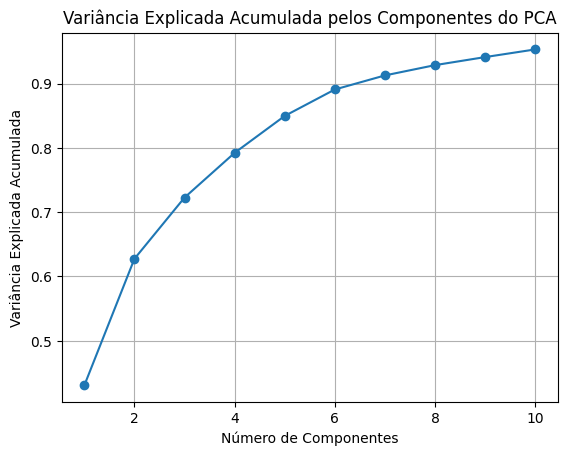

In [7]:

# Standardize features before PCA
X = StandardScaler().fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Apply PCA
pca = PCA(n_components=10)  # reduce to 10 components
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train model on PCA-transformed data
model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train)
print("Test accuracy (PCA):", model.score(X_test_pca, y_test))

# Plota a variância explicada
plt.plot(range(1, 11), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title("Variância Explicada Acumulada pelos Componentes do PCA")
plt.xlabel("Número de Componentes")
plt.ylabel("Variância Explicada Acumulada")
plt.grid()
plt.show()


### Algoritmo Genético (Single-Objective)

gen	nevals	avg     	max     
0  	50    	0.963634	0.980671
1  	45    	0.970527	0.978932
2  	39    	0.974953	0.980671
3  	38    	0.975904	0.982441
4  	45    	0.976569	0.982441
5  	38    	0.976148	0.982441
6  	38    	0.978465	0.982441
7  	32    	0.979799	0.984195
8  	42    	0.981274	0.984195
9  	43    	0.980712	0.984195
10 	48    	0.980959	0.984195
11 	40    	0.981346	0.984195
12 	47    	0.981735	0.984195
13 	39    	0.982332	0.984195
14 	43    	0.982156	0.984195
15 	42    	0.983421	0.984195
16 	35    	0.983984	0.984195
17 	40    	0.983949	0.984195
18 	47    	0.984019	0.984195
19 	41    	0.984055	0.984195
20 	42    	0.984125	0.984195


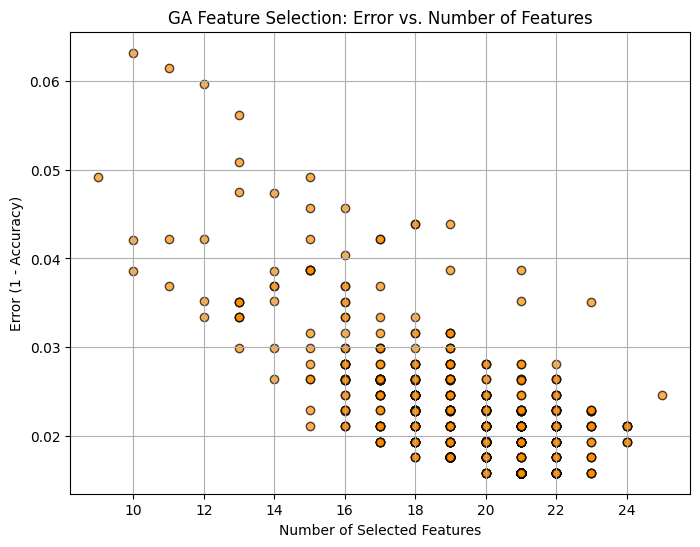


Best Feature Subset Indices: [0, 1, 4, 7, 8, 9, 10, 11, 12, 13, 14, 15, 19, 21, 22, 23, 24, 26, 27, 28, 29] 21
Best Cross-Validation Accuracy: 0.9841950007762769
Chromosome: [1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1]


In [8]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
n_features = X.shape[1]
X = StandardScaler().fit_transform(X)

# Storage for all individuals evaluated
all_errors = []
all_selected = []

# Evaluation function with logging
def evaluate(individual):
	if sum(individual) == 0:
		all_errors.append(1.0)
		all_selected.append(0)
		return 0.0,

	selected_indices = [i for i, bit in enumerate(individual) if bit == 1]
	X_selected = X[:, selected_indices]
	clf = LogisticRegression(max_iter=1000)
	score = cross_val_score(clf, X_selected, y, cv=5).mean()

	# Track error and number of features
	error = 1 - score
	all_errors.append(error)
	all_selected.append(len(selected_indices))
	return score,

# GA setup
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=n_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

# Run GA
random.seed(42)
pop = toolbox.population(n=50)
NGEN = 20
HALL_OF_FAME = tools.HallOfFame(1)

stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("max", np.max)

pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=0.8, mutpb=0.1, ngen=NGEN,
								   stats=stats, halloffame=HALL_OF_FAME, verbose=True)


plt.figure(figsize=(8, 6))
plt.scatter(all_selected, all_errors, alpha=0.7, color='darkorange', edgecolor='k')
plt.xlabel("Number of Selected Features")
plt.ylabel("Error (1 - Accuracy)")
plt.title("GA Feature Selection: Error vs. Number of Features")
plt.grid(True)
plt.show()
plt.show()


#  Best solution
best_individual = HALL_OF_FAME[0]
selected_features = [i for i, bit in enumerate(best_individual) if bit == 1]
print("\nBest Feature Subset Indices:", selected_features, len(selected_features))
print("Best Cross-Validation Accuracy:", evaluate(best_individual)[0])
print("Chromosome:", best_individual)


# Interpretabilidade

## Importância das características usando Decison Tree

Feature ranking:
1. mean concave points (0.7212)
2. worst texture (0.1202)
3. worst area (0.0688)
4. worst radius (0.0404)
5. worst fractal dimension (0.0175)
6. area error (0.0139)
7. worst smoothness (0.0107)
8. texture error (0.0073)
9. worst compactness (0.0000)
10. worst perimeter (0.0000)
11. fractal dimension error (0.0000)
12. worst concavity (0.0000)
13. worst concave points (0.0000)
14. worst symmetry (0.0000)
15. concavity error (0.0000)
16. concave points error (0.0000)
17. symmetry error (0.0000)
18. smoothness error (0.0000)
19. perimeter error (0.0000)
20. radius error (0.0000)
21. mean fractal dimension (0.0000)
22. compactness error (0.0000)
23. mean symmetry (0.0000)
24. mean concavity (0.0000)
25. mean compactness (0.0000)
26. mean smoothness (0.0000)
27. mean area (0.0000)
28. mean perimeter (0.0000)
29. mean texture (0.0000)
30. mean radius (0.0000)


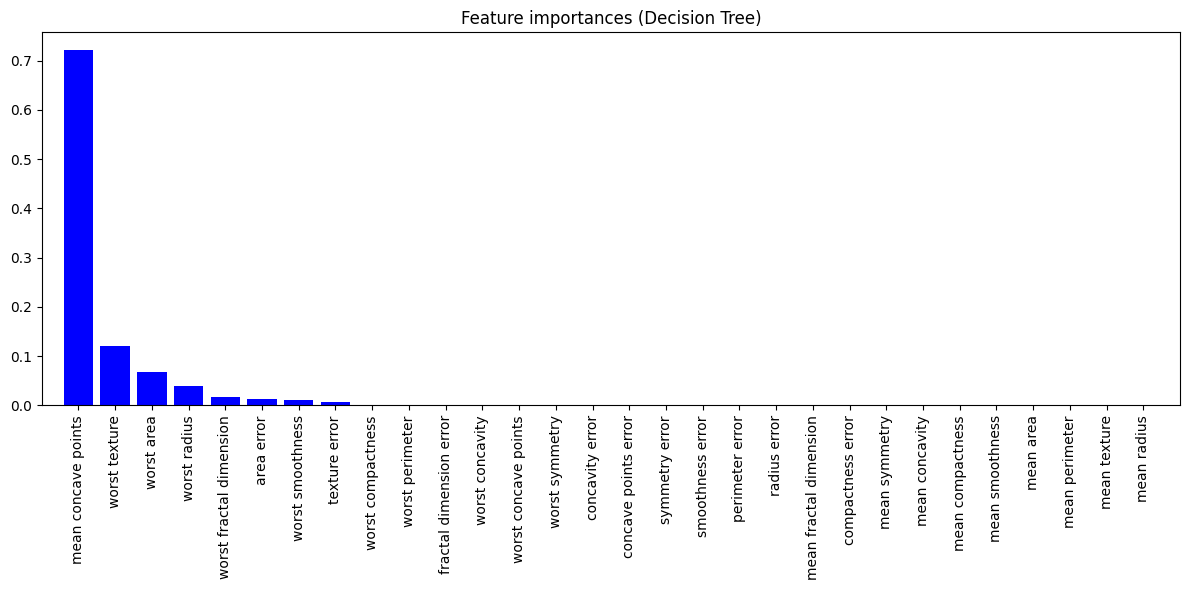

In [9]:
# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train a Decision Tree classifier
dt = DecisionTreeClassifier(max_depth=4, random_state=42)  # Limiting depth for better interpretability
dt.fit(X_train, y_train)

# Get feature importances
importances = dt.feature_importances_

# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")
for f in range(X.shape[1]):
    print(f"{f + 1}. {feature_names[indices[f]]} ({importances[indices[f]]:.4f})")

# Plot the feature importances
plt.figure(figsize=(12, 6))
plt.title("Feature importances (Decision Tree)")
plt.bar(range(X.shape[1]), importances[indices], color="b", align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()


## Importância das características usando Random Forest

Feature ranking:
1. mean concave points (0.1419)
2. worst concave points (0.1271)
3. worst area (0.1182)
4. mean concavity (0.0806)
5. worst radius (0.0780)
6. worst perimeter (0.0743)
7. mean perimeter (0.0601)
8. mean area (0.0538)
9. worst concavity (0.0411)
10. mean radius (0.0323)
11. area error (0.0295)
12. worst texture (0.0188)
13. worst compactness (0.0175)
14. radius error (0.0164)
15. worst symmetry (0.0129)
16. perimeter error (0.0118)
17. worst smoothness (0.0118)
18. mean texture (0.0111)
19. mean compactness (0.0092)
20. fractal dimension error (0.0071)
21. worst fractal dimension (0.0069)
22. mean smoothness (0.0062)
23. smoothness error (0.0059)
24. concavity error (0.0058)
25. compactness error (0.0046)
26. symmetry error (0.0040)
27. concave points error (0.0034)
28. mean symmetry (0.0033)
29. texture error (0.0032)
30. mean fractal dimension (0.0031)


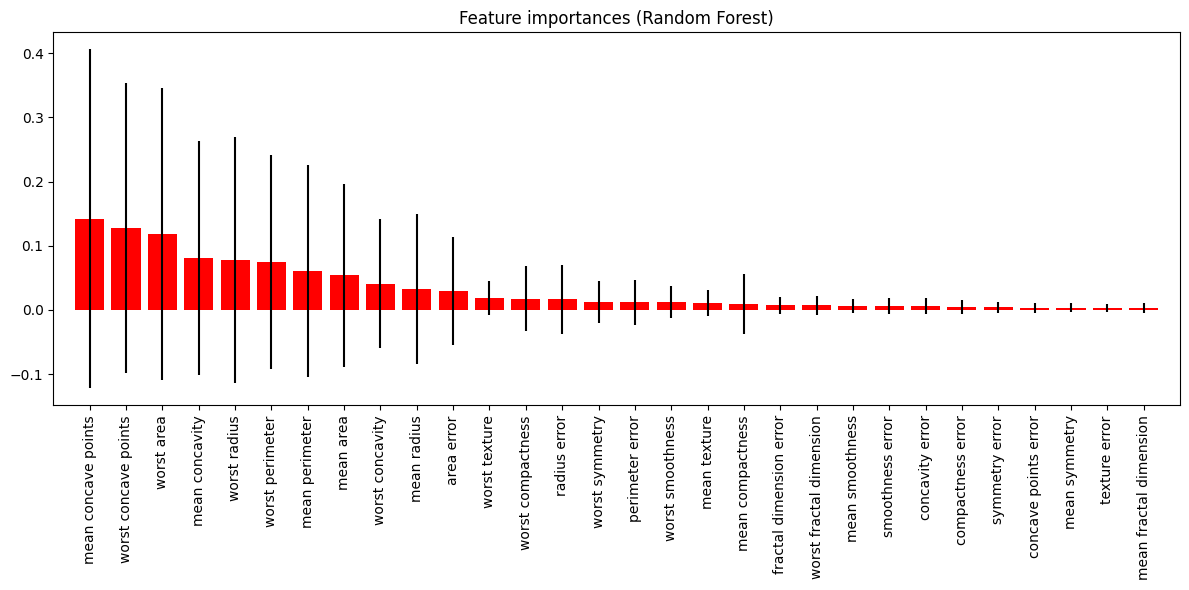

In [10]:

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train a Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")
for f in range(X.shape[1]):
    print(f"{f + 1}. {feature_names[indices[f]]} ({importances[indices[f]]:.4f})")

# Plot the feature importances
plt.figure(figsize=(12, 6))
plt.title("Feature importances (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices],
        color="r", yerr=std[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()

## Permutation Feature Importance

Test Accuracy: 0.958041958041958


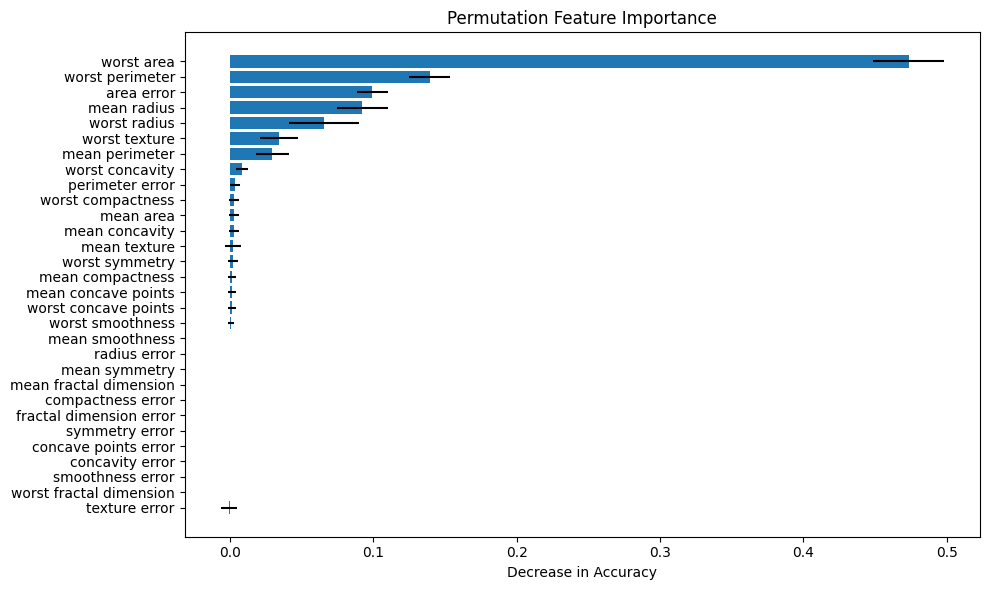

In [11]:

# Load dataset
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target
feature_names = data.feature_names

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Fit logistic regression (with regularization and scaling)
model = LogisticRegression(max_iter=1000, solver='liblinear')
#model = DecisionTreeClassifier ()

model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Permutation importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Convert to DataFrame and sort
importance_df = pd.DataFrame({
	'feature': feature_names,
	'importance_mean': result.importances_mean,
	'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance_mean'], xerr=importance_df['importance_std'])
plt.xlabel("Decrease in Accuracy")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Partial Dependence (PD) and Individual Conditional Expectation (ICE)

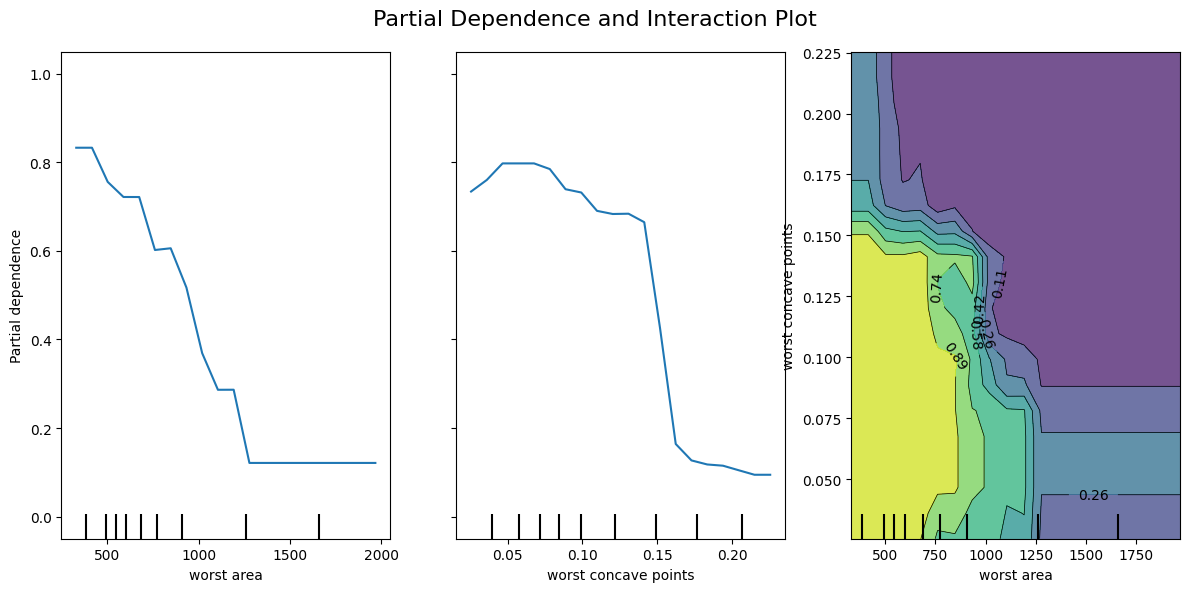

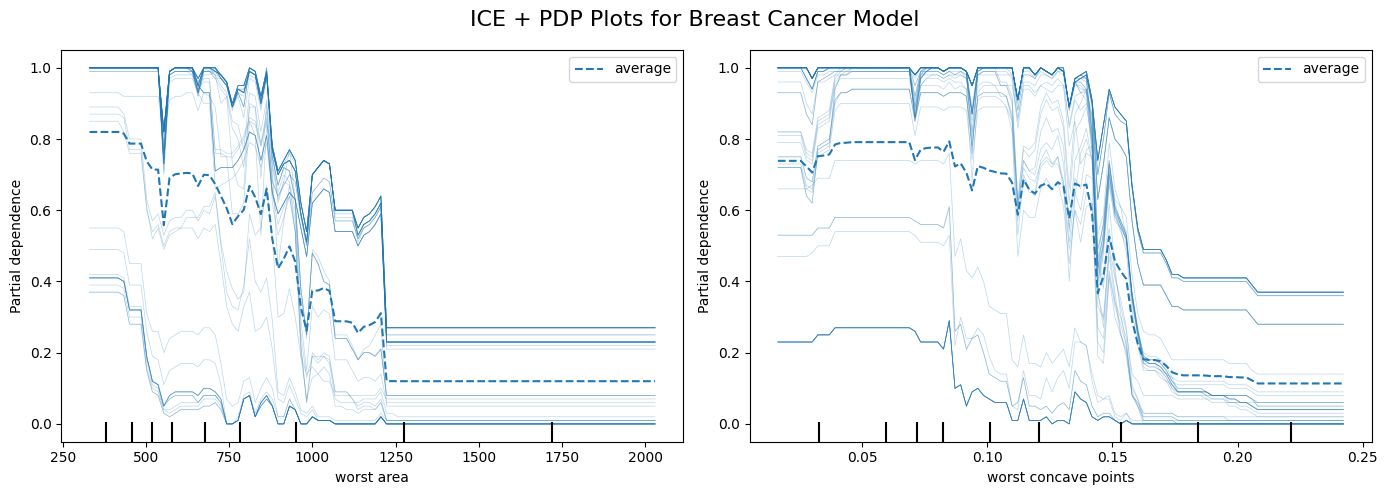

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay

# Load and prepare data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

top_2_features = ['worst area', 'worst concave points']
X_selected = X[top_2_features]
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# PDP + interaction plot
fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(
    estimator=model,
    X=X_train,
    features=[0, 1, (0, 1)],               # PDP for each feature + interaction
    feature_names=top_2_features,
    ax=ax,
    grid_resolution=20
)
plt.suptitle("Partial Dependence and Interaction Plot", fontsize=16)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(14, 5))

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=['worst area'],
    kind='both',             # show ICE + PDP
    ax=ax[0],
    subsample=50,            # show ICE for 50 samples
    random_state=42
)

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=['worst concave points'],
    kind='both',             # show ICE + PDP
    ax=ax[1],
    subsample=50,
    random_state=42
)

plt.suptitle("ICE + PDP Plots for Breast Cancer Model", fontsize=16)
plt.tight_layout()
plt.show()

## SHAP Values

In [13]:

import shap
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Get predictions and probabilities
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# SHAP explainer
explainer = shap.Explainer(model, X_train)

shap_values = explainer(X_train)


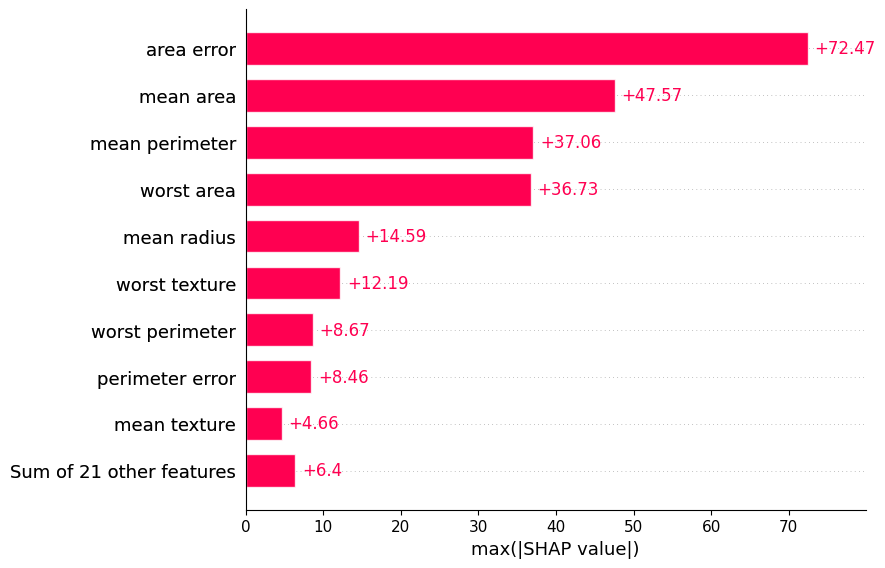

In [14]:
#shap.plots.bar(shap_values)
shap.plots.bar(shap_values.abs.max(0))

In [15]:
print ('Some samples')
for i in range (10):
	print (i, y_pred[i], y_test[i], y_proba[i] )

print ('All the misclassified samples')
for i in range (len(y_pred)):
  if (y_pred[i] != y_test[i]):
  	print (i, y_pred[i], y_test[i], y_proba[i] )

Some samples
0 1 1 [0.13911082 0.86088918]
1 0 0 [9.99999951e-01 4.92145370e-08]
2 0 0 [0.99818499 0.00181501]
3 1 1 [0.00128954 0.99871046]
4 1 1 [2.32487684e-04 9.99767512e-01]
5 0 0 [1.00000000e+00 2.08575785e-10]
6 0 0 [1.00000000e+00 6.65958515e-11]
7 0 0 [0.98092923 0.01907077]
8 1 1 [0.02023355 0.97976645]
9 1 1 [0.00603774 0.99396226]
All the misclassified samples
20 1 0 [0.20521593 0.79478407]
58 1 0 [0.33265389 0.66734611]
112 0 1 [0.93262197 0.06737803]
120 0 1 [0.90531499 0.09468501]


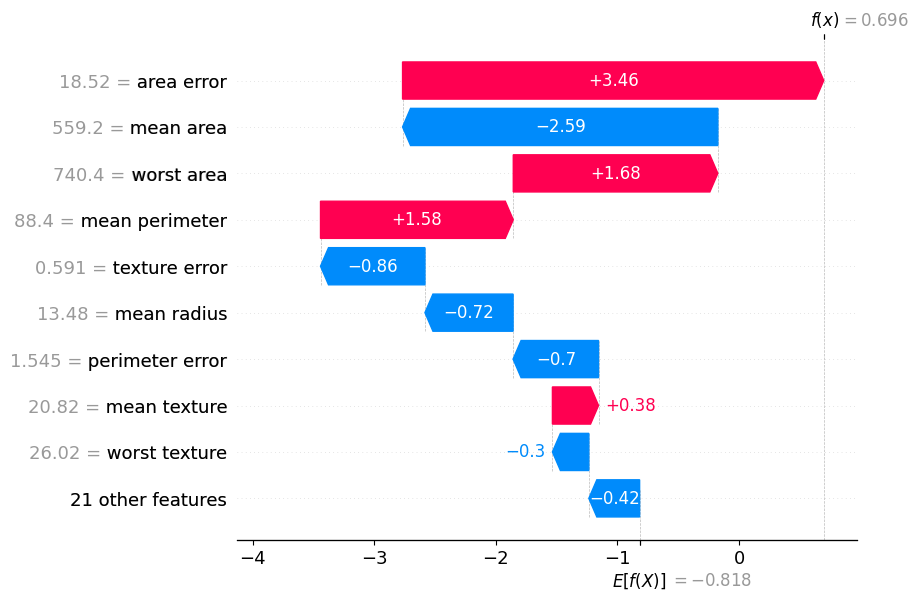

In [16]:

# Pick a sample
instance_index = 58
x_instance = X_test.iloc[[instance_index]]

# Compute SHAP values
shap_values = explainer(x_instance)

# Plot waterfall
shap.plots.waterfall(shap_values[0], max_display=10)

## LIME

In [17]:
import lime
import lime.lime_tabular
import numpy as np

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Optional: scale the data (important for some models, like SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# Create LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
	training_data=X_train_scaled,
	feature_names=feature_names,
	class_names=data.target_names,
	mode='classification'
)


In [18]:

# Pick an instance to explain
i = 0  # index of test instance
exp = explainer.explain_instance(
	X_test_scaled[i],
	model.predict_proba,
	num_features=10
)

# Show explanation
exp.show_in_notebook(show_table=True, show_all=False)